In [1]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.model_selection import LeaveOneGroupOut, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
import time
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import cross_val_predict

df = pd.read_pickle("../Data/feature_database.pkl")
df = df[~df['Activity'].astype(str).str.contains('_')]

meta_cols = ['Subject', 'Timestamp', 'Activity', 'Gait', 'Reps']
gonio_cols = [col for col in df.columns if '_Target' in col]
feature_cols = [col for col in df.columns if col not in meta_cols + gonio_cols]

for sub in df['Subject'].unique():
    sub_mask = df['Subject'] == sub
    scaler = StandardScaler()
    df.loc[sub_mask, feature_cols] = scaler.fit_transform(df.loc[sub_mask, feature_cols])

X = df[feature_cols].values
y = df['Activity'].values
groups = df['Subject'].values

print(f"Total features entering PCA: {len(feature_cols)}")
print("=" * 60)

model_grids = {
    "Logistic Regression": {
        "model": LogisticRegression(max_iter=2000, random_state=42, n_jobs=-1),
        "params": {
            "classifier__C": [0.01, 0.1, 1.0, 10.0]
        }
    },
    "SVM": {
        "model": SVC(kernel='rbf', random_state=42),
        "params": {
            "classifier__C": [0.1, 1.0, 10.0, 50.0],
            "classifier__gamma": ['scale', 'auto', 0.01, 0.1]
        }
    },
    "Random Forest": {
        "model": RandomForestClassifier(random_state=42, n_jobs=-1),
        "params": {
            "classifier__n_estimators": [100, 200],
            "classifier__max_depth": [5, 10, None],
            "classifier__min_samples_leaf": [5, 15, 30]
        }
    },
    "Gradient Boosting": {
        "model": HistGradientBoostingClassifier(random_state=42),
        "params": {
            "classifier__learning_rate": [0.01, 0.1],
            "classifier__max_depth": [5, 10, None],
            "classifier__min_samples_leaf": [15, 30]
        }
    }
}

logo = LeaveOneGroupOut()
best_models = {}

for model_name, config in model_grids.items():
    print(f"\nTuning: {model_name}")
    start_time = time.time()
    
    pipeline = Pipeline([
        ('pca', PCA(n_components=0.99, random_state=42)),
        ('classifier', config['model'])
    ])
    
    grid_search = GridSearchCV(
        estimator=pipeline,
        param_grid=config['params'],
        cv=logo,
        scoring='accuracy',
        n_jobs=-1,
        return_train_score=True
    )
    
    grid_search.fit(X, y, groups=groups)
    
    elapsed = time.time() - start_time
    best_idx = grid_search.best_index_
    
    print(f"Optimal parameters: {grid_search.best_params_}")
    
    # Iterate through the splits to print fold-specific scores for the best model
    for fold, (train_idx, test_idx) in enumerate(logo.split(X, y, groups)):
        test_subject = groups[test_idx[0]]
        train_acc = grid_search.cv_results_[f'split{fold}_train_score'][best_idx]
        test_acc = grid_search.cv_results_[f'split{fold}_test_score'][best_idx]
        
        print(f"Fold {fold+1} (Sub {test_subject}): Train = {train_acc:.4f} | Test = {test_acc:.4f}")

    avg_train = grid_search.cv_results_['mean_train_score'][best_idx]
    avg_test = grid_search.cv_results_['mean_test_score'][best_idx]
    
    print(f"Average Train: {avg_train:.4f} | Average Test: {avg_test:.4f}")
    print(f"Time taken: {elapsed:.1f} seconds")

    best_models[model_name] = grid_search.best_estimator_

Total features entering PCA: 78

Tuning: Logistic Regression
Optimal parameters: {'classifier__C': 0.01}
Fold 1 (Sub 01): Train = 0.9523 | Test = 0.6285
Fold 2 (Sub 09): Train = 0.9337 | Test = 0.8909
Fold 3 (Sub 10): Train = 0.9384 | Test = 0.7579
Fold 4 (Sub 13): Train = 0.9315 | Test = 0.9137
Fold 5 (Sub 16): Train = 0.9296 | Test = 0.9005
Fold 6 (Sub 17): Train = 0.9344 | Test = 0.9073
Average Train: 0.9366 | Average Test: 0.8331
Time taken: 44.2 seconds

Tuning: SVM
Optimal parameters: {'classifier__C': 0.1, 'classifier__gamma': 'auto'}
Fold 1 (Sub 01): Train = 0.9647 | Test = 0.6788
Fold 2 (Sub 09): Train = 0.9639 | Test = 0.9031
Fold 3 (Sub 10): Train = 0.9601 | Test = 0.7821
Fold 4 (Sub 13): Train = 0.9584 | Test = 0.9429
Fold 5 (Sub 16): Train = 0.9559 | Test = 0.9117
Fold 6 (Sub 17): Train = 0.9572 | Test = 0.9395
Average Train: 0.9600 | Average Test: 0.8597
Time taken: 1748.5 seconds

Tuning: Random Forest
Optimal parameters: {'classifier__max_depth': None, 'classifier__min_

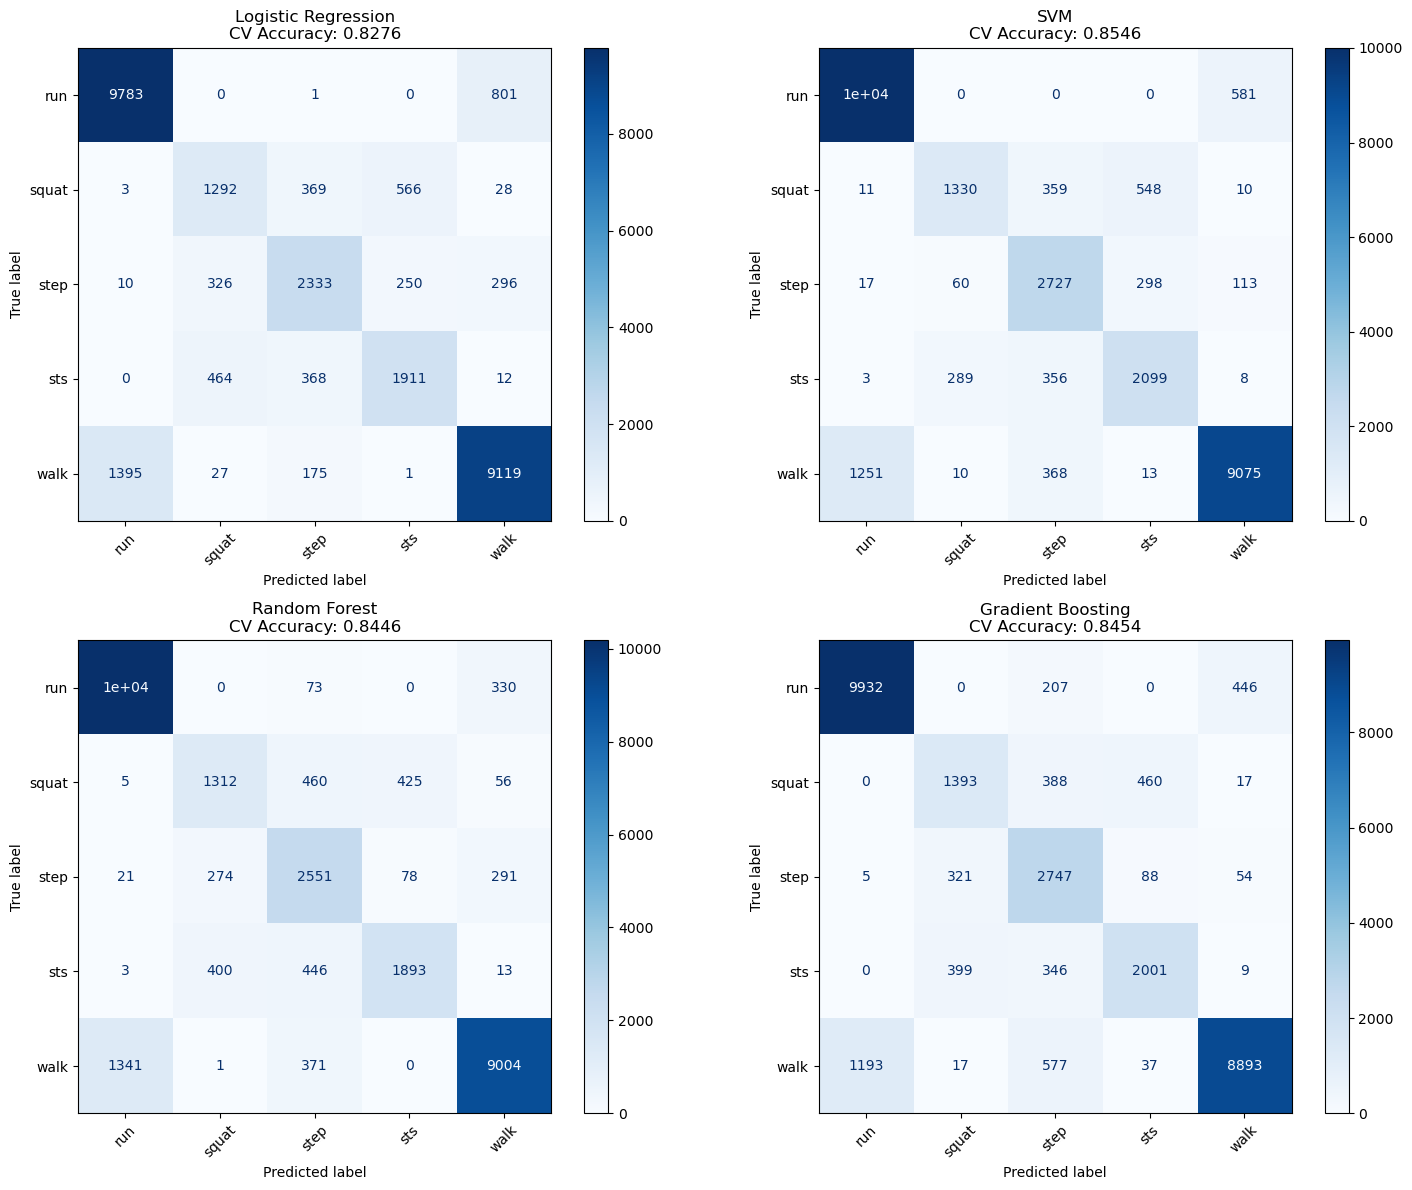

In [2]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.flatten()

unique_classes = np.unique(y)

for idx, (model_name, best_pipeline) in enumerate(best_models.items()):
    
    # Generate cross-validated predictions using the optimal pipeline and LOGO
    y_pred = cross_val_predict(best_pipeline, X, y, groups=groups, cv=logo, n_jobs=-1)
    
    # Build and plot the matrix
    cm = confusion_matrix(y, y_pred, labels=unique_classes)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=unique_classes)
    
    disp.plot(cmap='Blues', ax=axes[idx], xticks_rotation=45)
    axes[idx].set_title(f"{model_name}\nCV Accuracy: {np.mean(y == y_pred):.4f}")

plt.tight_layout()
plt.show()